# Vocalno plot (Baseline visit)

##  Import transcript-level abundance (Baseline visit)

In [ ]:
Txi_script <- readRDS("Txi_script_BL.rds")

File downloaded:

• Txi_script_24DEC7.rds <id: 12OnCLxuc0rAMr_d6EtMLNp2oWzBo_me8>

Saved locally as:

• Txi_script_24DEC7.rds



In [5]:
myTPM <- Txi_script$abundance
myCounts <- Txi_script$counts
library(tidyverse)
drive_download(as_id("12DfosyDt5oyfBPXU9Yzv9haOJRwSOowq"), path = "metaDataIR3.csv", overwrite = TRUE)
sam.BL.fil <- read_csv("metaDataIR3.csv") %>%
  dplyr::filter(DIAGNOSIS %in% c("PD", "Control"), CLINICAL_EVENT == "BL", QCflagIR3 == "pass")

File downloaded:

• metaDataIR3.csv <id: 12DfosyDt5oyfBPXU9Yzv9haOJRwSOowq>

Saved locally as:

• metaDataIR3.csv

New names:
• `Specimen Bar Code` -> `Specimen Bar Code...3`
• `Specimen Bar Code` -> `Specimen Bar Code...8`
Rows: 4871 Columns: 72
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): HudAlphaID, QCflagIR3, Specimen Bar Code...3, GENDER, DIAGNOSIS, C...
dbl (63): PATNO, Quantity (ug), Concentration (ng/ul), Concentration Flag, S...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
library(edgeR)
dge <- DGEList(myCounts)
log2.cpm <- cpm(dge, log = TRUE)
log2.cpm.df <- as_tibble(log2.cpm, rownames = "geneID")

In [7]:
drive_download(as_id("1H4S8r4VcJ-GpBzxDip7ME5EdZW2ggDvS"), path = "PAR.UPDRS2.BL.RData", overwrite = TRUE)
# Load the .RData file
load("PAR.UPDRS2.BL.RData")
agedf <- dplyr::select( PAR.UPDRS2.BL, PATNO, ENROLL_AGE)

File downloaded:

• PAR.UPDRS2.BL.RData <id: 1H4S8r4VcJ-GpBzxDip7ME5EdZW2ggDvS>

Saved locally as:

• PAR.UPDRS2.BL.RData



In [12]:
groups2 <- factor(sam.BL.fil2$DIAGNOSIS)
keepTheseGenes4 <-filterByExpr(dge, group = groups2)

In [13]:
dge.filtered <- dge[keepTheseGenes4,]
dim(dge.filtered)
dge.filtered.norm <- calcNormFactors(dge.filtered, method = "TMM")

[1] 95569   582

In [14]:
log2.cpm.filtered.norm <- cpm(dge.filtered.norm, log = TRUE)
log2.cpm.filtered.norm.df <- as_tibble(log2.cpm.filtered.norm, rownames = "geneID")

In [15]:
head(log2.cpm.filtered.norm.df)

geneID,3201,4117,3471,3435,3173,3479,4110,3174,3454,⋯,3788,3807,3809,3854,3863,3867,3868,3904,3102,3418
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENST00000456328.2,-1.75536331,-2.7277863,-2.31776929,-0.7053399,-1.71852494,-0.4171748,-1.3796648,-1.7105432,-1.453366886,⋯,-0.3268079,-0.8171638,-1.285989878,-1.3866720,-0.70694002,-0.4731773,-0.5062164,-0.3974117,-1.966552105,-0.2692299
ENST00000488147.1,-1.22636564,-1.4023670,-0.73189890,-1.2013187,-1.04222314,-0.6257597,-0.8969784,-0.7433572,-0.703487205,⋯,-0.5677291,-0.9046285,-0.861894347,-1.3708850,0.07040206,-1.0337487,-0.8989597,-0.2989409,0.192462385,-0.4035860
ENST00000461467.1,2.02724750,2.4814812,2.41195200,1.9682301,1.40271789,0.7656834,2.2129789,1.7014641,1.505714077,⋯,1.5495862,1.4202519,1.844043308,1.8992600,1.69696703,1.5806608,0.7536989,0.3471835,1.504275266,1.1216413
ENST00000466430.5,-0.06661282,-0.3500703,-0.05342682,0.1538780,-0.03217241,-0.4913824,0.1884468,-0.0269818,0.007172341,⋯,0.3183738,-0.1273917,-0.003902386,0.3379028,0.45692494,0.3561020,-0.5391353,-0.6151312,0.090361070,0.3835922
ENST00000471248.1,0.77904482,1.6042775,1.13827649,0.9592382,0.79088834,0.7018447,1.5885237,1.8710509,1.248509715,⋯,1.3783315,0.7246598,0.160560384,1.4434459,1.74842841,0.8997966,1.2869529,0.1757427,0.870843282,0.7417831
ENST00000610542.1,-1.54909781,-3.6955609,-1.87797488,-1.2146516,-2.41707876,-3.2403707,-4.6274645,-1.4736522,-2.720287533,⋯,-1.3566992,-2.2834585,0.097031224,-1.6226160,1.33990659,-0.7946678,-1.9572944,-3.0319882,0.002214629,-1.1328982


In [16]:
log2.cpm.filtered.norm.df.pivot <- pivot_longer(log2.cpm.filtered.norm.df,
                                                cols = '3201':last_col(),,
                                                names_to = "samples",
                                                values_to = "expression")

In [17]:
head(log2.cpm.filtered.norm.df.pivot)

geneID,samples,expression
<chr>,<chr>,<dbl>
ENST00000456328.2,3201,-1.7553633
ENST00000456328.2,4117,-2.7277863
ENST00000456328.2,3471,-2.3177693
ENST00000456328.2,3435,-0.7053399
ENST00000456328.2,3173,-1.7185249
ENST00000456328.2,3479,-0.4171748


In [18]:
library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(biomaRt)

In [21]:
# ANNOTATION ----
ensembl <- useEnsembl(biomart = "ensembl",
                   dataset = "hsapiens_gene_ensembl")
# Clean the transcript IDs to remove version information
transcript_ids <- log2.cpm.filtered.norm.df$geneID
clean_transcript_ids <- gsub("\\..*", "", transcript_ids)  # Remove the version number

# Retrieve gene symbols for all transcript IDs in one go
gene_info <- getBM(
  filters = "ensembl_transcript_id",
  attributes = c("ensembl_transcript_id", "external_gene_name"),
  values = clean_transcript_ids,
  mart = ensembl
)

# Merge gene_info with the log2.cpm.filtered.norm.df dataframe
NAME.log2.cpm.filtered.norm.df <- log2.cpm.filtered.norm.df %>%
  mutate(ensembl_transcript_id = clean_transcript_ids) %>%
  left_join(gene_info, by = "ensembl_transcript_id")

# Rearrange the dataframe to have gene symbols as the first column if external_gene_name exists
if ("external_gene_name" %in% colnames(NAME.log2.cpm.filtered.norm.df)) {
  NAME.log2.cpm.filtered.norm.df <- NAME.log2.cpm.filtered.norm.df %>%
    dplyr::select(external_gene_name, everything())
}



In [22]:

# Create variables containing Specimen Bar Code for HC and PD samples
hc_id <- sam.BL.fil %>% dplyr::filter(DIAGNOSIS == "Control") %>% pull('PATNO')
pd_id <- sam.BL.fil %>% dplyr::filter(DIAGNOSIS == "PD") %>% pull('PATNO')

# Match these Specimen Bar Codes to the corresponding column names in NAME.log2.cpm.filtered.norm.df
hc_columns <- colnames(NAME.log2.cpm.filtered.norm.df)[colnames(NAME.log2.cpm.filtered.norm.df) %in% hc_id]
pd_columns <- colnames(NAME.log2.cpm.filtered.norm.df)[colnames(NAME.log2.cpm.filtered.norm.df) %in% pd_id]

In [23]:
head(NAME.log2.cpm.filtered.norm.df
)

external_gene_name,geneID,3201,4117,3471,3435,3173,3479,4110,3174,⋯,3807,3809,3854,3863,3867,3868,3904,3102,3418,ensembl_transcript_id
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
DDX11L16,ENST00000456328.2,-1.75536331,-2.7277863,-2.31776929,-0.7053399,-1.71852494,-0.4171748,-1.3796648,-1.7105432,⋯,-0.8171638,-1.285989878,-1.3866720,-0.70694002,-0.4731773,-0.5062164,-0.3974117,-1.966552105,-0.2692299,ENST00000456328
WASH7P,ENST00000488147.1,-1.22636564,-1.4023670,-0.73189890,-1.2013187,-1.04222314,-0.6257597,-0.8969784,-0.7433572,⋯,-0.9046285,-0.861894347,-1.3708850,0.07040206,-1.0337487,-0.8989597,-0.2989409,0.192462385,-0.4035860,ENST00000488147
FAM138A,ENST00000461467.1,2.02724750,2.4814812,2.41195200,1.9682301,1.40271789,0.7656834,2.2129789,1.7014641,⋯,1.4202519,1.844043308,1.8992600,1.69696703,1.5806608,0.7536989,0.3471835,1.504275266,1.1216413,ENST00000461467
,ENST00000466430.5,-0.06661282,-0.3500703,-0.05342682,0.1538780,-0.03217241,-0.4913824,0.1884468,-0.0269818,⋯,-0.1273917,-0.003902386,0.3379028,0.45692494,0.3561020,-0.5391353,-0.6151312,0.090361070,0.3835922,ENST00000466430
,ENST00000471248.1,0.77904482,1.6042775,1.13827649,0.9592382,0.79088834,0.7018447,1.5885237,1.8710509,⋯,0.7246598,0.160560384,1.4434459,1.74842841,0.8997966,1.2869529,0.1757427,0.870843282,0.7417831,ENST00000471248
NA,ENST00000610542.1,-1.54909781,-3.6955609,-1.87797488,-1.2146516,-2.41707876,-3.2403707,-4.6274645,-1.4736522,⋯,-2.2834585,0.097031224,-1.6226160,1.33990659,-0.7946678,-1.9572944,-3.0319882,0.002214629,-1.1328982,ENST00000610542


In [24]:
# Calculate the averages and log fold change using mutate
mydata.df <- NAME.log2.cpm.filtered.norm.df %>%
  mutate(
    healthy.AVG = rowMeans(dplyr::select(., all_of(hc_columns)), na.rm = TRUE),
    disease.AVG = rowMeans(dplyr::select(., all_of(pd_columns)), na.rm = TRUE),
    LogFC = disease.AVG - healthy.AVG
  ) %>%
  mutate_if(is.numeric, round, 2)

In [25]:
sam.BL.fil2 <- transform(sam.BL.fil2,
                         ENROLL_AGE = scale(ENROLL_AGE),
                         `RIN Value` = scale(`RIN Value`))

In [26]:
# Create the design matrix (ensure all column names are valid)
design <- model.matrix(~ 0 + DIAGNOSIS + ENROLL_AGE + Sex + Plate + `RIN Value`,
                       data = transform(sam.BL.fil2,
                                        DIAGNOSIS = factor(DIAGNOSIS),
                                        Sex = factor(GENDER),
                                        Plate = factor(Plate)))



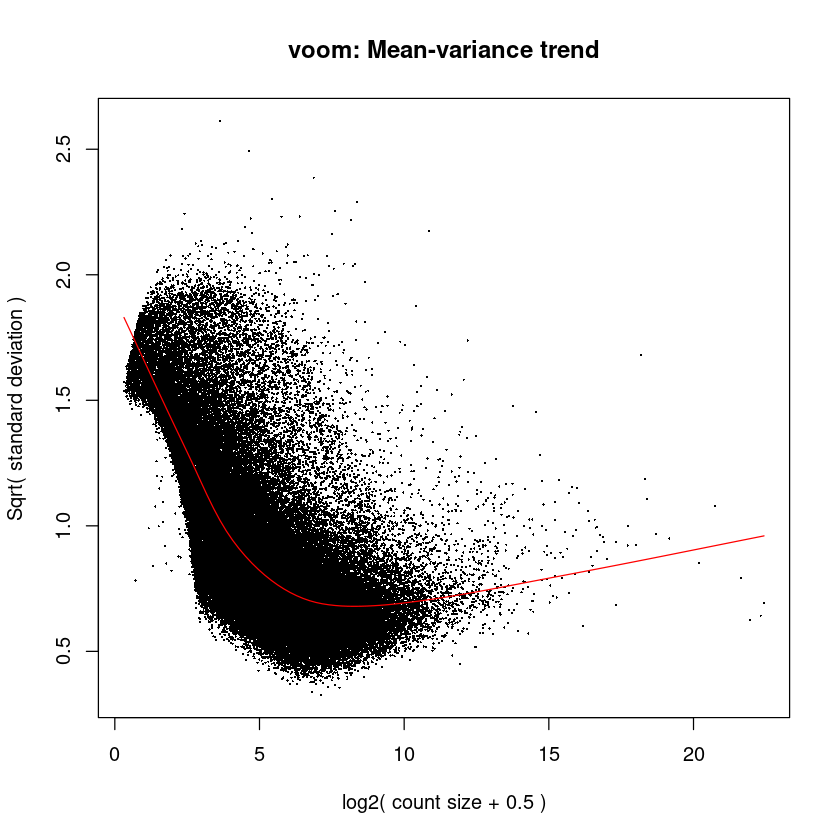

In [27]:
# Clean up column names in the design matrix
colnames(design) <- make.names(colnames(design))

# Fit the linear model to the voom-transformed data
v.DEGLIST.filtered.norm <- voom(dge.filtered.norm, design, plot = TRUE)
# Use voomWithQualityWeights to account for sample quality differences

fit <- lmFit(v.DEGLIST.filtered.norm, design)

# Create the contrast matrix
contrast.matrix <- makeContrasts(PD_vs_Control = DIAGNOSISPD - DIAGNOSISControl, levels = design)

# Extract the linear model fit and apply Bayesian statistics
fits <- contrasts.fit(fit, contrast.matrix)
ebFit <- eBayes(fits)

# Write results to a file (optional)
# write.fit(ebFit, file = "lmfit_results.txt")

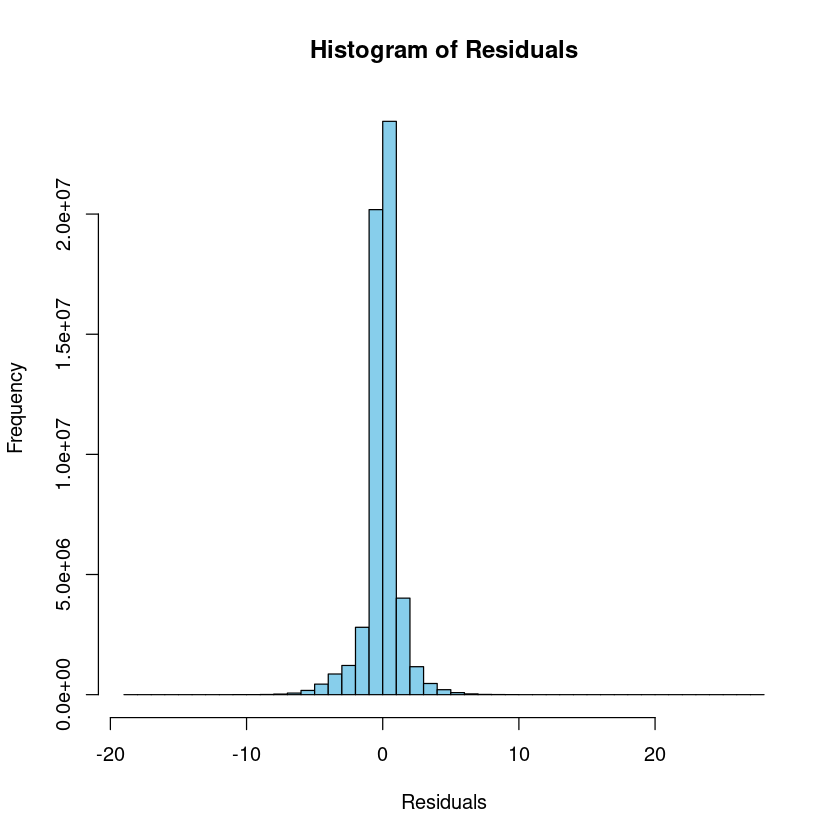

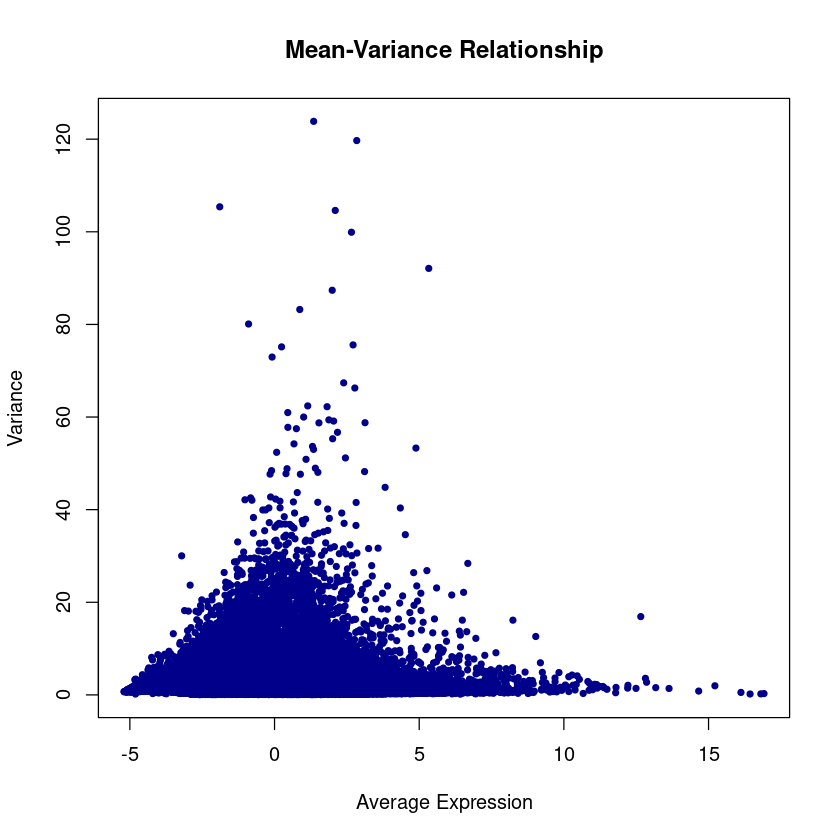

In [28]:

residuals_data <- residuals(fit, y = v.DEGLIST.filtered.norm$E)
hist(residuals_data, main = "Histogram of Residuals", xlab = "Residuals", col = "skyblue", breaks = 50)
plot(fit$Amean, fit$sigma^2, xlab = "Average Expression", ylab = "Variance",
     main = "Mean-Variance Relationship", col = "darkblue", pch = 20)


In [29]:
myTopHits <- topTable(ebFit, adjust ="BH", coef=1, number=Inf, sort.by="logFC")
myTopHits

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENST00000502897.5,2.520086,-4.3756447,4.0247834,6.498882e-05,8.140127e-03,-1.2212118
ENST00000457954.5,-1.850252,-4.0171778,-12.0972848,4.763499e-30,4.552428e-25,54.1679540
ENST00000520504.1,-1.784564,-3.9037254,-10.8934268,3.645225e-25,1.741852e-20,43.6468708
ENST00000384507.1,1.694840,-3.6484035,2.7256097,6.621957e-03,8.194381e-02,-2.8494553
ENST00000475580.5,1.571524,-4.2375330,7.2567390,1.351307e-12,1.434923e-08,16.3175340
ENST00000463374.5,-1.477304,-3.6663868,-7.3578761,6.804837e-13,8.129143e-09,17.7966800
ENST00000377791.3,-1.440401,1.8160889,-4.1284828,4.216248e-05,6.517695e-03,1.8047263
ENST00000573239.1,1.354858,-3.2336449,3.9416525,9.131705e-05,9.480954e-03,0.2911907
ENST00000631654.1,-1.337380,-4.1593870,-9.6337039,2.084130e-20,6.639273e-16,32.8452836


In [30]:
myTopHits$transcripts <- rownames(myTopHits)
myTopHits2.df <- myTopHits %>%
  as_tibble(rownames = "geneID")%>%
  left_join(mydata.df, by = "geneID") %>%
  dplyr::select(logFC,P.Value, external_gene_name, adj.P.Val,t, B, AveExpr,	transcripts)%>%
  dplyr::mutate(sig = case_when(
    abs(logFC)>=0.01 &
      adj.P.Val < 0.05 ~ "sig",
    TRUE ~ "not sig"
  ))

In [33]:
myTopHits2.df <- myTopHits2.df %>%
  dplyr::arrange(adj.P.Val)  # Sort by adj.P.Val in ascending order

View(myTopHits2.df)

logFC,P.Value,external_gene_name,adj.P.Val,t,B,AveExpr,transcripts,sig
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
-1.8502523,4.763499e-30,ORC4,4.552428e-25,-12.097285,54.167954,-4.01717780,ENST00000457954.5,sig
-1.7845636,3.645225e-25,PANK3,1.741852e-20,-10.893427,43.646871,-3.90372539,ENST00000520504.1,sig
-1.3373803,2.084130e-20,SLC25A36,6.639273e-16,-9.633704,32.845284,-4.15938701,ENST00000631654.1,sig
-1.1211809,8.671932e-17,CNOT6,2.071920e-12,-8.593620,24.941302,-4.40860251,ENST00000618123.4,sig
1.0493814,3.644242e-16,ACAD9,6.965532e-12,8.405143,24.562749,-3.72906991,ENST00000514643.5,sig
-0.5694779,4.406461e-14,ZFYVE26,7.018685e-10,-7.751019,20.449666,-4.44456970,ENST00000557407.1,sig
0.9463524,4.793005e-13,OSBPL8,6.543753e-09,7.409124,17.448200,-3.85486094,ENST00000550628.5,sig
-1.4773035,6.804837e-13,MBNL1,8.129143e-09,-7.357876,17.796680,-3.66638676,ENST00000463374.5,sig
1.5715235,1.351307e-12,VPS8,1.434923e-08,7.256739,16.317534,-4.23753305,ENST00000475580.5,sig


In [51]:
# Define URLs
url1 <- "https://www.gsea-msigdb.org/gsea/msigdb/human/download_geneset.jsp?geneSetName=GOBP_NEUTROPHIL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE&fileType=TSV"
url2 <- "https://www.gsea-msigdb.org/gsea/msigdb/human/download_geneset.jsp?geneSetName=GOBP_NEUTROPHIL_CHEMOTAXIS&fileType=TSV"

# Load the TSV files directly from the URLs
file1 <- read.delim(url1, header = TRUE, stringsAsFactors = FALSE)
file2 <- read.delim(url2, header = TRUE, stringsAsFactors = FALSE)

# Extract the row where STANDARD_NAME == "GENE_SYMBOLS" and split the gene lists
gene_row1 <- file1[file1$STANDARD_NAME == "GENE_SYMBOLS", ]
gene_list1 <- unlist(strsplit(as.character(gene_row1$GOBP_NEUTROPHIL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE), split = ","))

gene_row2 <- file2[file2$STANDARD_NAME == "GENE_SYMBOLS", ]
gene_list2 <- unlist(strsplit(as.character(gene_row2$GOBP_NEUTROPHIL_CHEMOTAXIS), split = ","))

# Combine the two gene lists and remove duplicates
combined_gene_list <- unique(c(gene_list1, gene_list2))

# Print the combined gene list
print("Combined Gene List:")
print(combined_gene_list)


[1] "Combined Gene List:"
  [1] "LILRA2"   "DNASE1"   "DNASE1L3" "FCER1G"   "ANXA3"    "ITGAM"   
  [7] "ITGB2"    "MYD88"    "CD177"    "PTAFR"    "BCR"      "SCNN1B"  
 [13] "SPI1"     "STXBP2"   "STXBP3"   "VAMP2"    "VAMP7"    "SYK"     
 [19] "TYROBP"   "PRAM1"    "VAMP8"    "CD300H"   "DNM1L"    "VAV3"    
 [25] "CXCL13"   "TIRAP"    "JAML"     "CCR7"     "CSF3R"    "CXADR"   
 [31] "MOSPD2"   "DPEP1"    "DPP4"     "EDN1"     "EDN2"     "EDN3"    
 [37] "PIKFYVE"  "PIP5K1C"  "DAPK2"    "C5AR2"    "CXCL1"    "CXCL2"   
 [43] "CXCL3"    "NCKAP1L"  "IL1B"     "CXCL8"    "CXCR1"    "CXCR2"   
 [49] "CXCL10"   "ITGA1"    "ITGA9"    "LBP"      "LGALS3"   "MIR223"  
 [55] "MDK"      "CXCL9"    "MPP1"     "CKLF"     "PDE4B"    "IL23A"   
 [61] "PF4"      "PF4V1"    "PIK3CD"   "PIK3CG"   "PLA2G1B"  "TREM1"   
 [67] "PPBP"     "PPIA"     "PPIB"     "CAMK1D"   "PREX1"    "RAC1"    
 [73] "RAC2"     "S100A8"   "S100A9"   "S100A12"  "SAA1"     "CCL3"    
 [79] "CCL19"    "CCL21"    "CXCL6"   

In [52]:
myTopHits2.df.sig <- dplyr::filter(myTopHits2.df,sig=="sig")

In [ ]:
filtered_data <- myTopHits2.df.sig %>%
  dplyr::filter(adj.P.Val <0.035, external_gene_name %in% combined_gene_list,
                logFC>0.05) %>%
  group_by(external_gene_name) %>%
  slice_min(order_by = adj.P.Val, n = 1) %>%
  ungroup() %>%
  dplyr::select(external_gene_name, logFC, adj.P.Val) %>%
  mutate(y = -log10(adj.P.Val)) 

pdf("Volcano_NET3_25Jan11.pdf", width = 7, height = 10)

ggplot(myTopHits2.df, aes(x = logFC, y = -log10(adj.P.Val))) +
  geom_point(aes(color = sig), alpha = 1/2, size = 2) +
  scale_color_manual(values = c("not sig" = "darkblue", "sig" = "deeppink4"),
                     labels = c("not sig" = "Not Significance", "sig" = "Significance")) +
  ggrepel::geom_label_repel(
    data = filtered_data,
    aes(x = logFC, y = y, label = external_gene_name), # Ensure x and y values match the main plot
    box.padding = 0.35,
    point.padding = 1.5,
    segment.color = 'black', # Line color
    segment.size = 0.5,       # Line thickness
    direction = "both",       # Ensure flexibility in label placement
    max.overlaps = 22
  ) +
  geom_hline(yintercept = 1.3, linetype = "dashed", color = "darkred") +
  theme_bw(base_size = 14) +
  theme(
    legend.title = element_blank(),
    legend.position = "bottom",
    plot.title = element_text(hjust = 0.1, size = 20, face = "bold"),
    axis.title = element_text(size = 18, face = "bold"),
    panel.grid.major = element_line(size = 0.2, linetype = 'solid', color = "grey"),
    panel.grid.minor = element_line(size = 0.1, linetype = 'solid', color = "lightgrey")
  ) +
  labs(
    title = "PPMI (BL visit)",
    x = expression(atop("PD/Control", "(log"[2] ~ "FC)")),
    y = expression(-log[10] ~ (adj.p ~ value)),
    color = "Significance"
  ) +
  xlim(c(-1, 1)) + ylim(c(0, 5))

dev.off()

drive_upload("Volcano_NET3_25Jan11.pdf")


Warning message:
"Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`)."


pdf 
  2

Local file:

• Volcano_NET3_25Jan11.pdf

Uploaded into Drive file:

• Volcano_NET3_25Jan11.pdf <id: 16c7j0gewKZLY78jcQYpJLpw_pxLofuIw>

With MIME type:

• application/pdf

